<a href="https://colab.research.google.com/github/Fano-Rdz/Mineria_de_Datos/blob/main/Manuscrito-178584.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de manuscrito
Aplicar técnicas de minería de datos y aprendizaje automático para entrenar y evaluar distintos modelos de clasificación usando el dataset Digits (8×8). Posteriormente, se evaluará su desempeño clasificando dígitos manuscritos creados por el estudiante.

## Carga del dataset

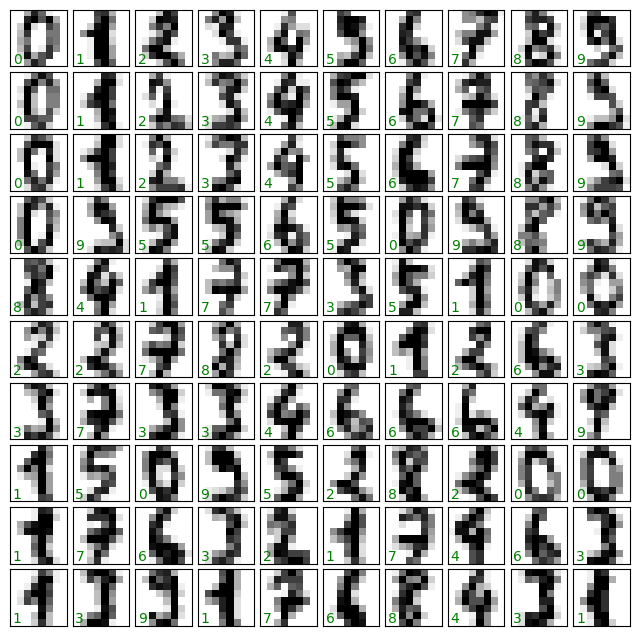

In [1]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.images.shape

import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

Division de entrenamiento

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 1437
Muestras de prueba: 360


Entrenamiento de modelo K-NN con k = 5

In [6]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Precisión del modelo KNN: {accuracy_knn:.4f}")

Precisión del modelo KNN: 0.9861


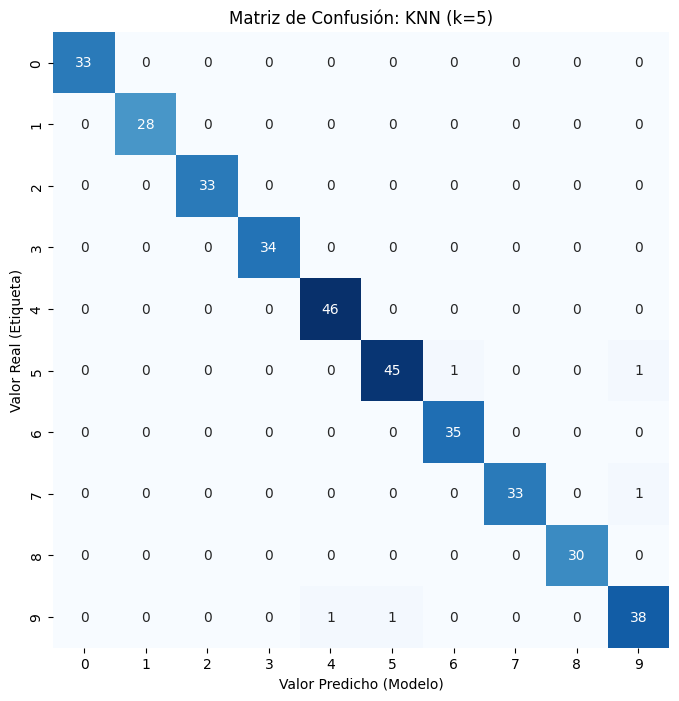

In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generar la matriz
mat = confusion_matrix(y_test, y_pred_knn)

# 2. Configurar el gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)

# 3. Etiquetas
plt.xlabel('Valor Predicho (Modelo)')
plt.ylabel('Valor Real (Etiqueta)')
plt.title('Matriz de Confusión: KNN (k=5)')
plt.show()

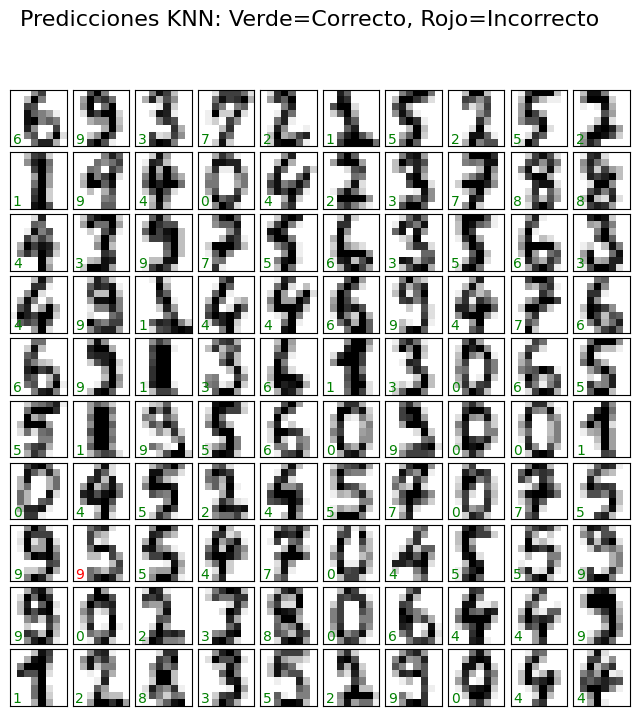

In [8]:
fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

test_images = X_test.reshape(-1, 8, 8)

for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i], cmap='binary', interpolation='nearest')

    is_correct = (y_test[i] == y_pred_knn[i])
    label_color = 'green' if is_correct else 'red'

    ax.text(0.05, 0.05, str(y_pred_knn[i]),
            transform=ax.transAxes,
            color=label_color)

plt.suptitle('Predicciones KNN: Verde=Correcto, Rojo=Incorrecto', fontsize=16)
plt.show()

In [13]:
from google.colab import files
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()



Saving uno.png to uno (4).png
Saving dos.png to dos (2).png
Saving cuatro.png to cuatro (2).png


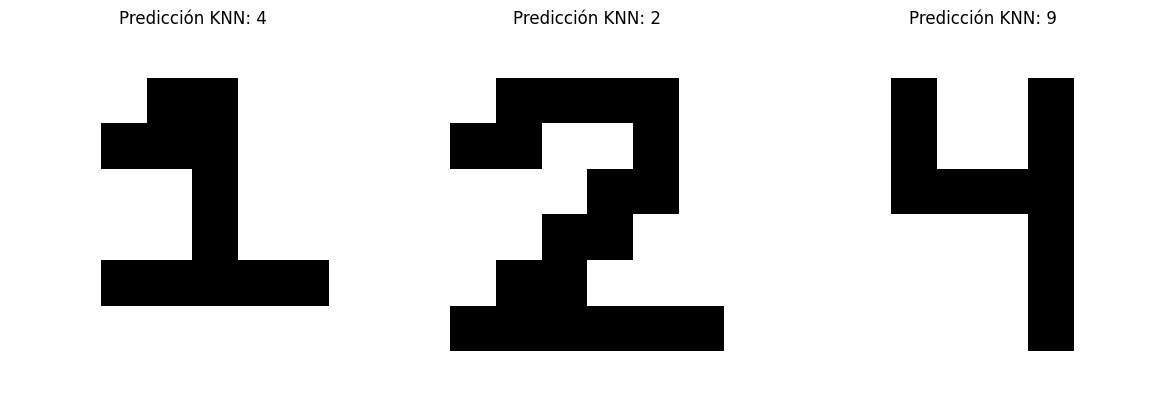

In [16]:
def procesar_imagen(data_imagen):
    img = Image.open(io.BytesIO(data_imagen)).convert('L')
    img_8x8 = img.resize((8, 8), Image.Resampling.LANCZOS)

    img_array = np.array(img_8x8, dtype=np.float32)
    img_final = (1.0 - (img_array / 255.0)) * 16.0
    return img_final

imagenes_procesadas = []
nombres = []

for nombre_archivo in uploaded.keys():
    img_8x8 = procesar_imagen(uploaded[nombre_archivo])
    imagenes_procesadas.append(img_8x8)
    nombres.append(nombre_archivo)

plt.figure(figsize=(12, 4))

for i in range(len(imagenes_procesadas)):
    dato_plano = imagenes_procesadas[i].reshape(1, -1)

    prediccion = knn_model.predict(dato_plano)[0]

    plt.subplot(1, 3, i + 1)
    plt.imshow(imagenes_procesadas[i], cmap='gray_r')
    plt.title(f"Predicción KNN: {prediccion}")
    plt.axis('off')

plt.tight_layout()
plt.show()